In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import os
import pandas as pd
import matplotlib.ticker as ticker

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

#plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [3]:
subdirectories = ['Hydrogen', 'Carbon dioxide', 'Ammonia', 'Methanol', 'Ethylene']
GWPFilePaths = [os.path.join('..', 'Results', 'Phase 2', subdir, f'{subdir.lower()} climate change results.xlsx') for subdir in subdirectories]

In [4]:
for GWPFilePath in GWPFilePaths:
    
    dfs = pd.read_excel(GWPFilePath, sheet_name = None)
    dfAll = []

    for df in dfs.items():
        database = df[0]
        df = df[1]
        numCols = len(df.columns) - 1
        repeatedActivity = np.repeat(df['Activity'], numCols)
        dfNew = pd.DataFrame({
            'Activity' : repeatedActivity,
            'Location' : np.tile(df.columns[1:], len(df)),
            'GWP' : df.iloc[:, 1:].values.flatten(),
            'Database' : database
        })
        dfAll.append(dfNew)

    GWPDF = pd.concat(dfAll, ignore_index = True)
    GWPDF = GWPDF.sort_values('Activity')

    if 'Hydrogen' in GWPFilePath:
        hydrogenGWPDF = GWPDF
        hydrogenBAUGWP = [row['GWP'] for index, row in hydrogenGWPDF.iterrows() if 'steam reforming' in row['Activity']
                                 and 'without electricity' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'biomethane' not in row['Activity']][0]
    elif 'Ammonia' in GWPFilePath:
        ammoniaGWPDF = GWPDF
        ammoniaBAUGWP = [row['GWP'] for index, row in ammoniaGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Methanol' in GWPFilePath:
        methanolGWPDF = GWPDF
        methanolBAUGWP = [row['GWP'] for index, row in methanolGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Ethylene' in GWPFilePath:
        ethyleneGWPDF = GWPDF
        ethyleneBAUGWP = [row['GWP'] for index, row in ethyleneGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]

In [5]:
def replace_values(df):
    df = df.copy()
    df['Database'] = df['Database'].str.replace('Base', 'RCP6')
    df['Database'] = df['Database'].str.replace('PkBudg500', 'RCP19')
    df['Database'] = df['Database'].str.replace('PkBudg1150', 'RCP26')
    return df

hydrogenGWPDF = replace_values(hydrogenGWPDF)
# carbonDioxideGWPDF = replace_values(carbonDioxideGWPDF)
ammoniaGWPDF = replace_values(ammoniaGWPDF)
methanolGWPDF = replace_values(methanolGWPDF)
ethyleneGWPDF = replace_values(ethyleneGWPDF)

In [6]:
hydrogenGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = hydrogenGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
# carbonDioxideGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = carbonDioxideGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ammoniaGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ammoniaGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
methanolGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = methanolGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ethyleneGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ethyleneGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')

hydrogenGWPDF['Pathway'] = hydrogenGWPDF['IAM'] + ' ' + hydrogenGWPDF['SSP'] + ' ' + hydrogenGWPDF['RCP']
# carbonDioxideGWPDF['Pathway'] = carbonDioxideGWPDF['IAM'] + ' ' + carbonDioxideGWPDF['SSP'] + ' ' + carbonDioxideGWPDF['RCP']
ammoniaGWPDF['Pathway'] = ammoniaGWPDF['IAM'] + ' ' + ammoniaGWPDF['SSP'] + ' ' + ammoniaGWPDF['RCP']
methanolGWPDF['Pathway'] = methanolGWPDF['IAM'] + ' ' + methanolGWPDF['SSP'] + ' ' + methanolGWPDF['RCP']
ethyleneGWPDF['Pathway'] = ethyleneGWPDF['IAM'] + ' ' + ethyleneGWPDF['SSP'] + ' ' + ethyleneGWPDF['RCP']

In [7]:
regionGroups = {
    'BRA' : ['Brazil'],
    'CAN' : ['Canada'],
    'CEU' : ['Albania', 'Bosnia and Herzegovina', 'Bulgaria', 'Cyprus', 'Czechia', 'Estonia', 'Croatia', 'Hungary', 'Lithuania',
             'Latvia', 'North Macedonia', 'Poland', 'Romania', 'Republic of Serbia', 'Slovenia', 'Slovakia', 'Kosovo', 'Northern Cyprus'],
    'CHN' : ['China', 'Mongolia', 'Taiwan'],
    'EAF' : ['Eritrea', 'Ethiopia', 'Kenya', 'Madagascar', 'Mauritius', 'Rwanda', 'Sudan', 'South Sudan', 'Somalia', 'Burundi', 'Djibouti',
             'Somaliland'],
    'INDIA' : ['India'],
    'INDO' : ['Indonesia', 'Papua New Guinea'],
    'JAP' : ['Japan'],
    'KOR' : ['North Korea', 'South Korea'],
    'ME' : ['United Arab Emirates', 'Bahrain', 'Israel', 'Iraq', 'Iran', 'Jordan', 'Kuwait', 'Lebanon', 'Montenegro', 'Saudi Arabia',
            'Oman', 'Yemen', 'Syria', 'Qatar', 'Palestine'],
    'MEX' : ['Mexico'],
    'NAF' : ['Algeria', 'Egypt', 'Libya', 'Morocco', 'Tunisia', 'Western Sahara'],
    'OCE' : ['Australia', 'New Zealand', 'Fiji', 'Vanuatu', 'New Caledonia', 'Solomon Islands'],
    'RCAM' : ['Costa Rica', 'Cuba', 'Curaçao', 'Dominican Republic', 'Guatemala', 'Honduras', 'Haiti', 'Jamaica', 'Nicaragua',
             'El Salvador', 'Trinidad and Tobago', 'The Bahamas', 'Puerto Rico', 'Panama', 'Belize'],
    'RSAF' : ['Angola', 'Botswana', 'Mozambique', 'Namibia', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe', 'Malawi', 'eSwatini', 'Lesotho', 'Uganda'],
    'RSAM' : ['Argentina', 'Falkland Is.', 'Bolivia', 'Chile', 'Colombia', 'Ecuador', 'Peru', 'Paraguay', 'Uruguay', 'Venezuela',
             'Guyana', 'Suriname'],
    'RSAS' : ['Bangladesh', 'Sri Lanka', 'Nepal', 'Pakistan', 'Bhutan', 'Afghanistan'],
    'RUS' : ['Armenia', 'Azerbaijan', 'Georgia', 'Russia'],
    'SAF' : ['South Africa'],
    'SEAS' : ['Brunei', 'Cambodia', 'Myanmar', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam', 'Laos'],
    'STAN' : ['Kyrgyzstan', 'Kazakhstan', 'Tajikistan', 'Turkmenistan', 'Uzbekistan'],
    'TUR' : ['Turkey'],
    'UKR' : ['Belarus', 'Moldova', 'Ukraine'],
    'USA' : ['United States of America'],
    'WAF' : ['Benin', 'Democratic Republic of the Congo', 'Republic of the Congo', 'Ivory Coast', 'Cameroon', 'Gabon', 'Gambia', 'Ghana', 'Niger', 'Nigeria',
             'Senegal', 'Togo', 'Mauritania', 'Mali', 'Burkina Faso', 'Chad', 'Central African Republic', 'Guinea-Bissau', 'Guinea',
             'Sierra Leone', 'Liberia', 'Equatorial Guinea'],
    'WEU' : ['Austria', 'Belgium', 'Switzerland', 'Germany', 'Denmark', 'Spain', 'Finland', 'France', 'United Kingdom', 'Gibraltar',
             'Greece', 'Ireland', 'Iceland', 'Italy', 'Luxembourg', 'Malta', 'Netherlands', 'Norway', 'Portugal', 'Sweden'],
}

In [8]:
newLocations = {'BR' : 'BRA',
                'CA' : 'CAN',
                'PL' : 'CEU',
                'CN' : 'CHN',
                'ET' : 'EAF',
                'IN' : 'INDIA',
                'ID' : 'INDO',
                'JP' : 'JAP',
                'KR' : 'KOR',
                'IR' : 'ME',
                'MX' : 'MEX',
                'EG' : 'NAF',
                'AU' : 'OCE',
                'GT' : 'RCAM',
                'BW' : 'RSAF',
                'CL' : 'RSAM',
                'PK' : 'RSAS',
                'RU' : 'RUS',
                'ZA' : 'SAF',
                'PH' : 'SEAS',
                'UZ' : 'STAN',
                'TR' : 'TUR',
                'UA' : 'UKR',
                'US' : 'USA',
                'NG' : 'WAF',
                'RER' : 'WEU'}

In [9]:
def find_key_by_value(dictionary, value):
    for key, val in dictionary.items():
        if key == value:
            return key
    return None

In [10]:
for key, value in newLocations.items():
    hydrogenGWPDF['Location'] = hydrogenGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    ammoniaGWPDF['Location'] = ammoniaGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    methanolGWPDF['Location'] = methanolGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    ethyleneGWPDF['Location'] = ethyleneGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))

In [11]:
# Define a custom color map from white to a specific color
colors = ['#D8D8D8', '#000000']  
cmapName = 'fossilColorMap'
customFossilMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

colors = ['#C5B3E5', '#52318E']  
cmapName = 'blueColorMap'
customBlueMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

colors = ['#FCACA6', '#B71205'] 
cmapName = 'solarColorMap'
customSolarMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

colors = ['#9EE1f1', '#167F99'] 
cmapName = 'windColorMap'
customWindMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

In [18]:
def plot_world_maps(title, dfHydrogen, dfAmmonia, dfMethanol, cmap):
    
    fig, ([ax1, ax3], [ax2, ax4]) = plt.subplots(2, 2, figsize = (fig_length[2], fig_height*0.4))
    plt.subplots_adjust(wspace = 0.1)

    world = gpd.read_file(r'/Users/abhinabera/Downloads/110m_cultural/ne_110m_admin_0_countries.shp')

    # Filter out Antarctica and Greenland
    world = world[world['SOVEREIGNT'] != 'Antarctica']
    world = world[world['ADMIN'] != 'Greenland']

    # Set up colormap and normalization based on GWP values
    combinedDF = pd.concat([dfHydrogen, dfAmmonia, dfMethanol], ignore_index = True)
    vmin = combinedDF['Percent'].min()
    vmax = combinedDF['Percent'].max()
    norm = plt.Normalize(vmin, vmax)

    ax1.set_title('a Hydrogen', fontweight = 'bold', fontsize = fontsize_title)
    ax2.set_title('c Methanol', fontweight = 'bold', fontsize = fontsize_title)
    ax3.set_title('b Ammonia', fontweight = 'bold', fontsize = fontsize_title)
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax3.set_yticks([])
    ax4.set_xticks([])
    ax4.set_yticks([])

    for region, countries in regionGroups.items():
        region_data = world[world['ADMIN'].isin(countries)]
        gwpValues1 = dfHydrogen[dfHydrogen['Location'] == region]['Percent']
        gwpValues2 = dfAmmonia[dfAmmonia['Location'] == region]['Percent']
        gwpValues3 = dfMethanol[dfMethanol['Location'] == region]['Percent']
        color1 = cmap(norm(gwpValues1))
        color2 = cmap(norm(gwpValues2))
        color3 = cmap(norm(gwpValues3))
        region_data.plot(ax = ax1, color = color1, label = region)
        region_data.plot(ax = ax2, color = color2, label = region)
        region_data.plot(ax = ax3, color = color3, label = region)
    
    ax1.set_xticks([])
    ax3.set_xticks([])

    # Create a single color bar outside the subplots
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Adjust the position as needed
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax, orientation='vertical')

    cbar.ax.set_ylabel('% change', rotation=90, labelpad=15)  # Replace with your desired label
    #cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    for ax in [ax1, ax2, ax3, ax4]:
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    path = os.path.join('..', 'Results', 'Phase 2', 'Regional BAU', title)
    plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Regional BAU', title + '.png')
    plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Regional BAU', title + '.svg')
    plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
    plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

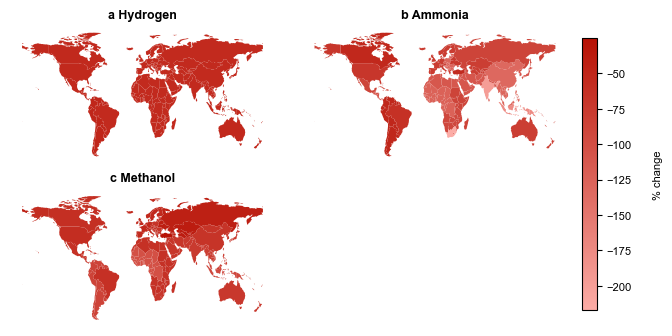

In [19]:
hydrogenSolarDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity')]
hydrogenBaseSolarDF = hydrogenSolarDF[hydrogenSolarDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenSolarDF.merge(hydrogenBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
hydrogenMergedDF['Percent'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP base']) / hydrogenMergedDF['GWP base']) * 100
hydrogenMergedDF = hydrogenMergedDF[~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenMergedDF.reset_index(drop = True)
hydrogenRCP262050 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2050') & hydrogenMergedDF['RCP'].str.contains('RCP26')]

ammoniaSolarDF = ammoniaGWPDF[ammoniaGWPDF['Activity'].str.contains('solar')]
ammoniaBaseSolarDF = ammoniaSolarDF[ammoniaSolarDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaSolarDF.merge(ammoniaBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ammoniaMergedDF['Percent'] = ((ammoniaMergedDF['GWP'] - ammoniaMergedDF['GWP base']) / ammoniaMergedDF['GWP base']) * 100
ammoniaMergedDF = ammoniaMergedDF[~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaMergedDF.reset_index(drop = True)
ammoniaRCP262050 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2050') & ammoniaMergedDF['RCP'].str.contains('RCP26')]

methanolSolarDF = methanolGWPDF[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
methanolBaseSolarDF = methanolSolarDF[methanolSolarDF['Database'].str.contains('2020')]
methanolMergedDF = methanolSolarDF.merge(methanolBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
methanolMergedDF['Percent'] = -((methanolMergedDF['GWP'] - methanolMergedDF['GWP base']) / methanolMergedDF['GWP base']) * 100
methanolMergedDF = methanolMergedDF[~methanolMergedDF['Database'].str.contains('2020')]
methanolMergedDF = methanolMergedDF.reset_index(drop = True)
methanolRCP262050 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2050') & methanolMergedDF['RCP'].str.contains('RCP26')]

plot_world_maps('Solar main', hydrogenRCP262050, ammoniaRCP262050, methanolRCP262050, customSolarMap)

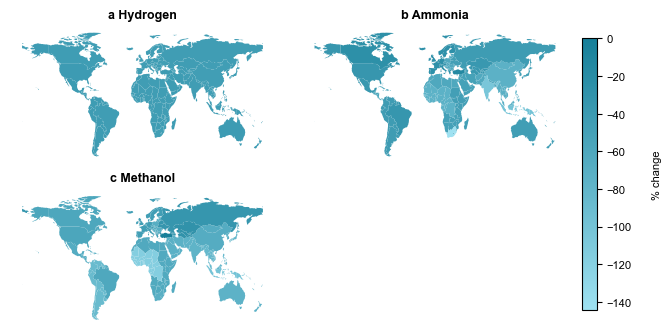

In [20]:
hydrogenWindDF = hydrogenGWPDF[hydrogenGWPDF['Activity'].str.contains('hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity')]
hydrogenBaseWindDF = hydrogenWindDF[hydrogenWindDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenWindDF.merge(hydrogenBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
hydrogenMergedDF['Percent'] = ((hydrogenMergedDF['GWP'] - hydrogenMergedDF['GWP base']) / hydrogenMergedDF['GWP base']) * 100
hydrogenMergedDF = hydrogenMergedDF[~hydrogenMergedDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenMergedDF.reset_index(drop = True)
hydrogenRCP262050 = hydrogenMergedDF[hydrogenMergedDF['Year'].str.contains('2050') & hydrogenMergedDF['RCP'].str.contains('RCP26')]

ammoniaWindDF = ammoniaGWPDF[ammoniaGWPDF['Activity'].str.contains('onshore wind')]
ammoniaBaseWindDF = ammoniaWindDF[ammoniaWindDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaWindDF.merge(ammoniaBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ammoniaMergedDF['Percent'] = ((ammoniaMergedDF['GWP'] - ammoniaMergedDF['GWP base']) / ammoniaMergedDF['GWP base']) * 100
ammoniaMergedDF = ammoniaMergedDF[~ammoniaMergedDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaMergedDF.reset_index(drop = True)
ammoniaRCP262050 = ammoniaMergedDF[ammoniaMergedDF['Year'].str.contains('2050') & ammoniaMergedDF['RCP'].str.contains('RCP26')]

methanolWindDF = methanolGWPDF[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
methanolBaseWindDF = methanolWindDF[methanolWindDF['Database'].str.contains('2020')]
methanolMergedDF = methanolWindDF.merge(methanolBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
methanolMergedDF['Percent'] = -((methanolMergedDF['GWP'] - methanolMergedDF['GWP base']) / methanolMergedDF['GWP base']) * 100
methanolMergedDF = methanolMergedDF[~methanolMergedDF['Database'].str.contains('2020')]
methanolMergedDF = methanolMergedDF.reset_index(drop = True)
methanolRCP262050 = methanolMergedDF[methanolMergedDF['Year'].str.contains('2050') & methanolMergedDF['RCP'].str.contains('RCP26')]

plot_world_maps('Wind main', hydrogenRCP262050, ammoniaRCP262050, methanolRCP262050, customWindMap)